In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars_bin/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'

#*************************** choose variable,factor and path
y2sec=-365.25*24*3600
factor = y2sec/10**12 #kg/s to GT/yr

variable2 = 'shelfmelt'

pth = pth_imip6hack

variable1 = 'shelfmelt'


pth1 = pth_helene

# variable2 = 'iareafl'
# factor = 1
# pth = pth_helene

# variable2 = 'iareagr'
# factor = 1
# pth = pth_helene


# variable2 = 'dslc_anom'
# factor = -1
# pth = pth_imip6hack

fpath = f'./figs/{variable2}_depthbin/'
fname = f'{variable2}_'

In [2]:

 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = [] # specify models to remove
 
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df_org = df.copy()
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]


In [3]:
df.iloc[i].Path

'/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalarsHelene/expAE02/shelfmelt/computed_shelfmelt_AIS_NORCE_CISM4-MAR364-ERA-t1-local_expAE02.nc'

In [6]:
dic_area_of_interest ={}
dic_area_of_interest['AIS']= ['']
dic_area_of_interest['WestAntarctica'] = ['_region_1']
dic_area_of_interest['EastAntarctica'] = ['_region_2']
dic_area_of_interest['Peninsula'] = ['_region_3']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['Filchner_Ronne'] = ['_sector_5','_sector_11']
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']
dic_area_of_interest['Aurora'] = ['_sector_8']
dic_area_of_interest['Wilkes'] = ['_sector_7']
renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3' 

The path './figs/shelfmelt_depthbin/' already exists.


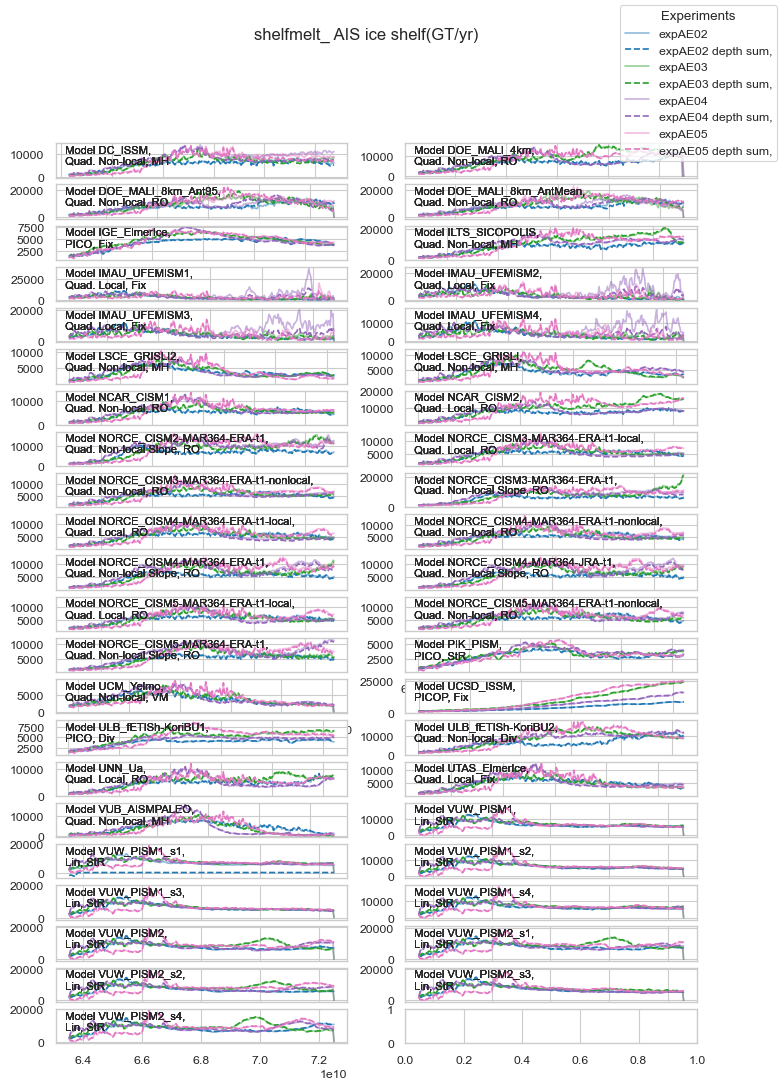

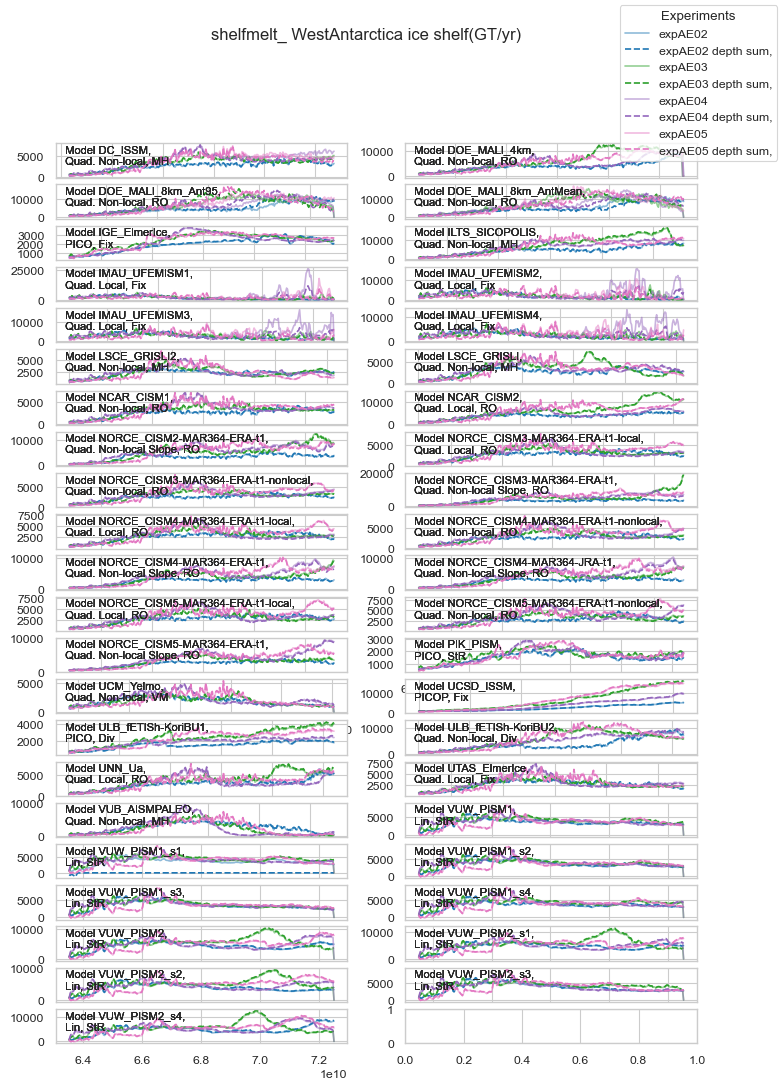

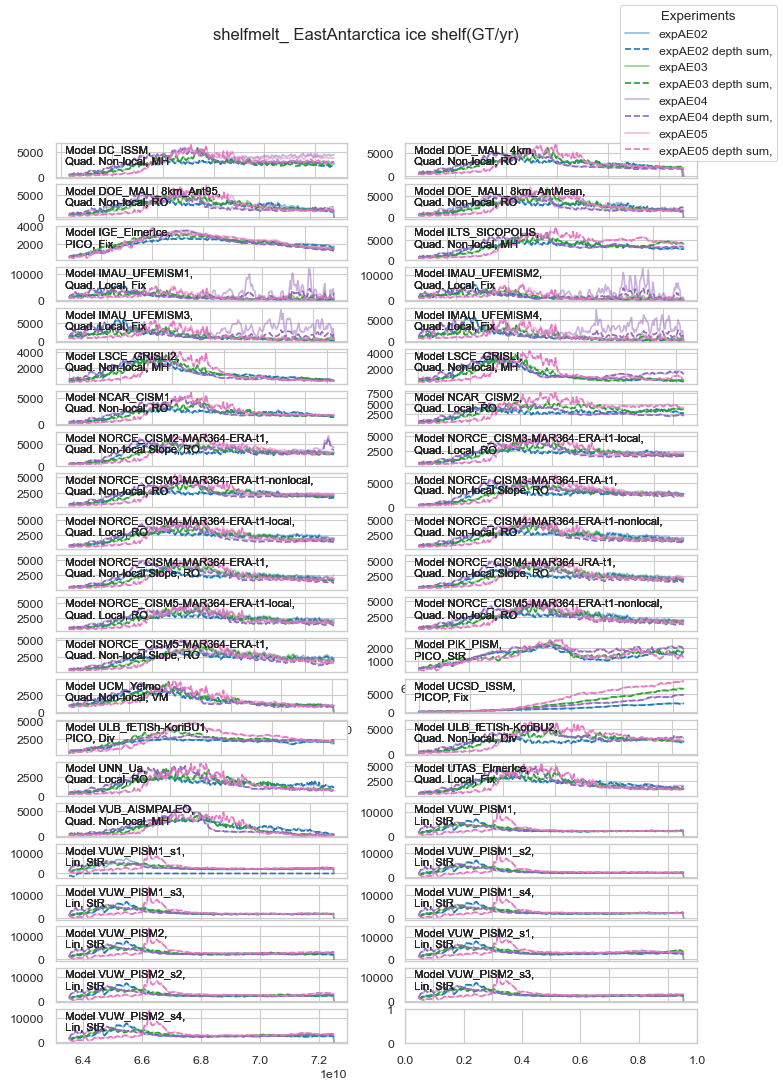

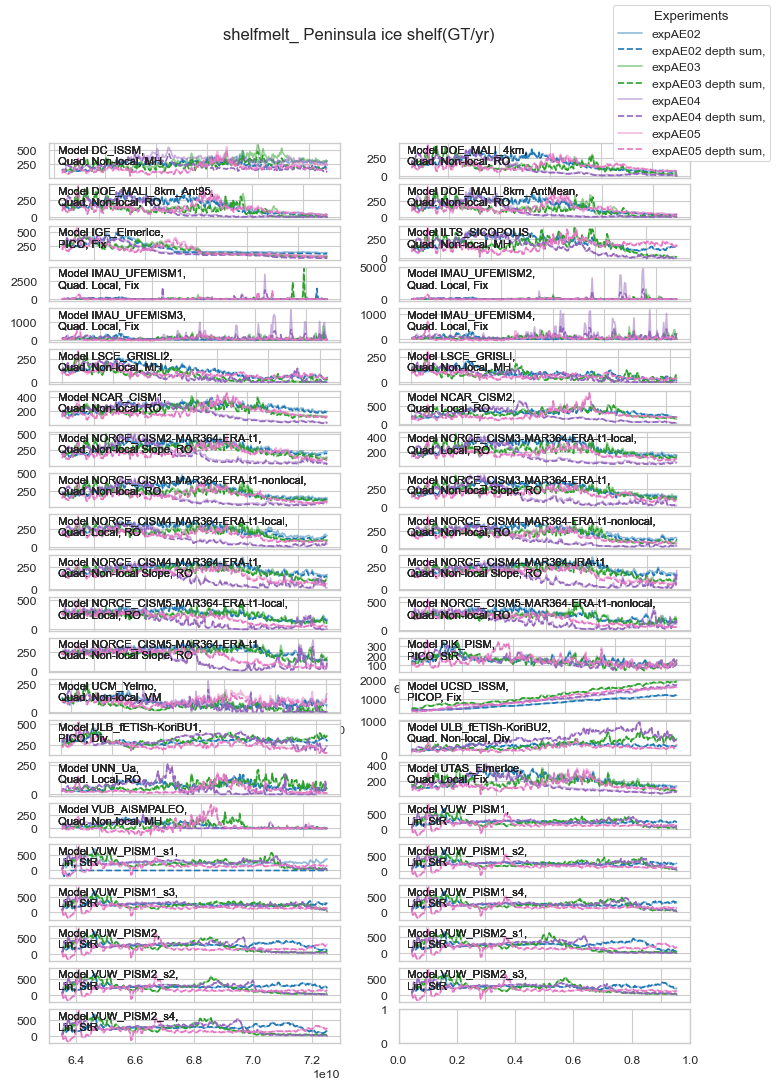

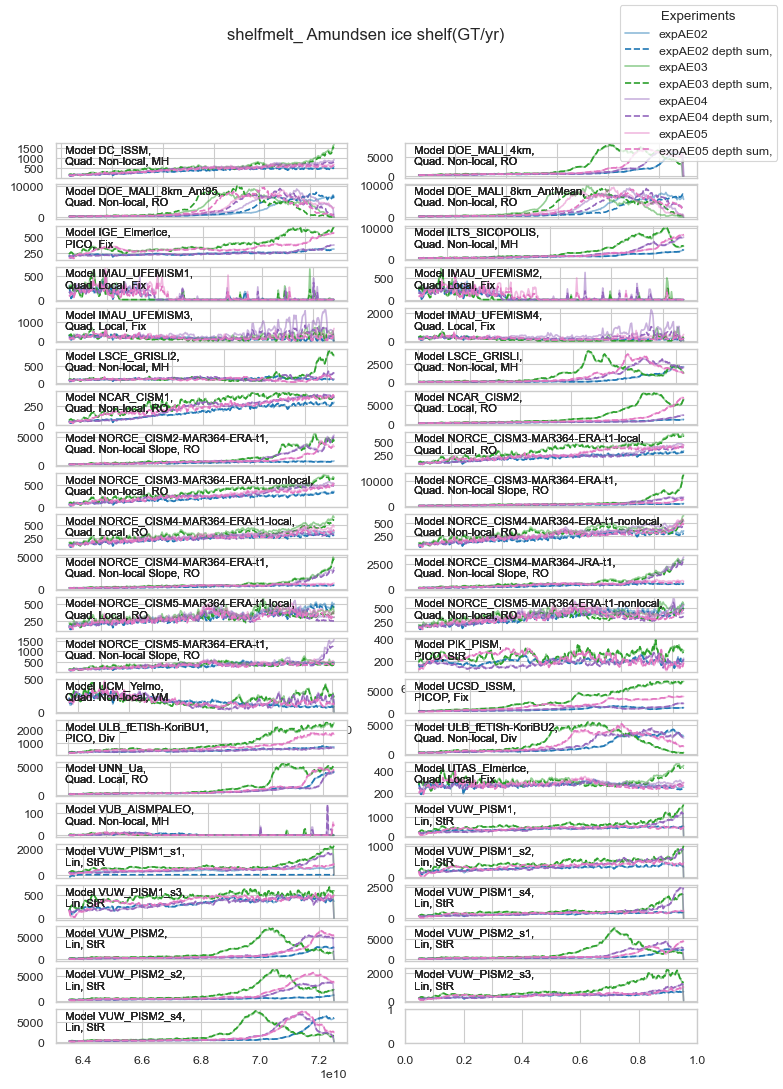

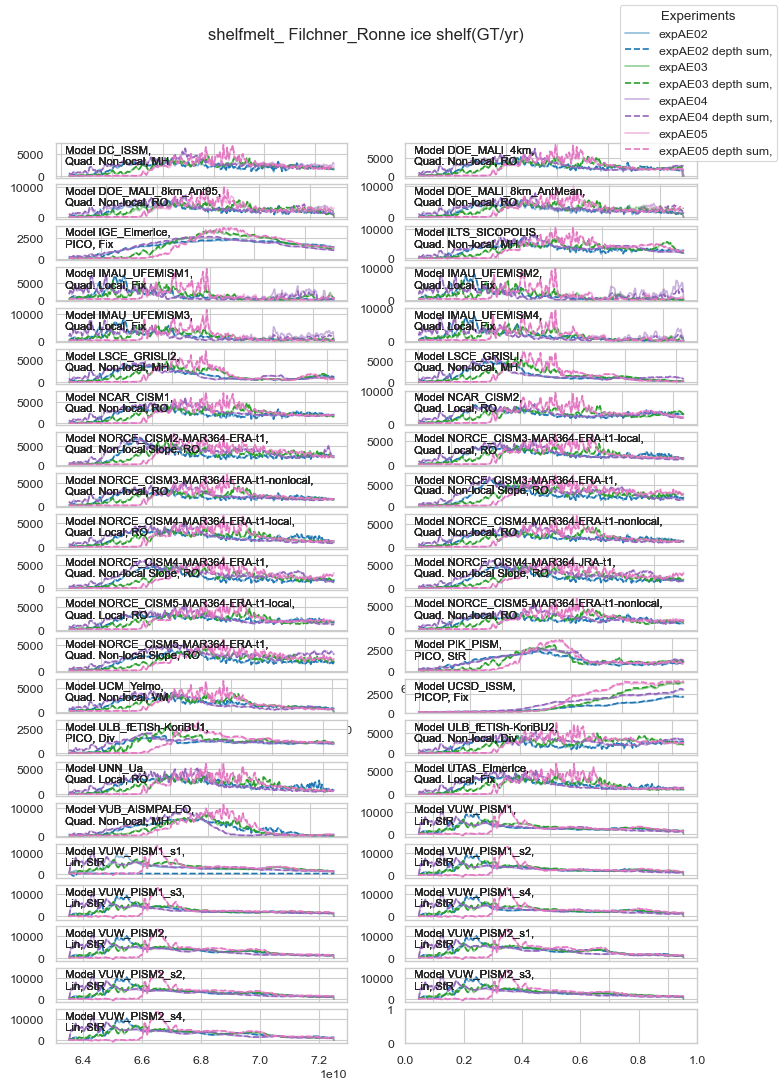

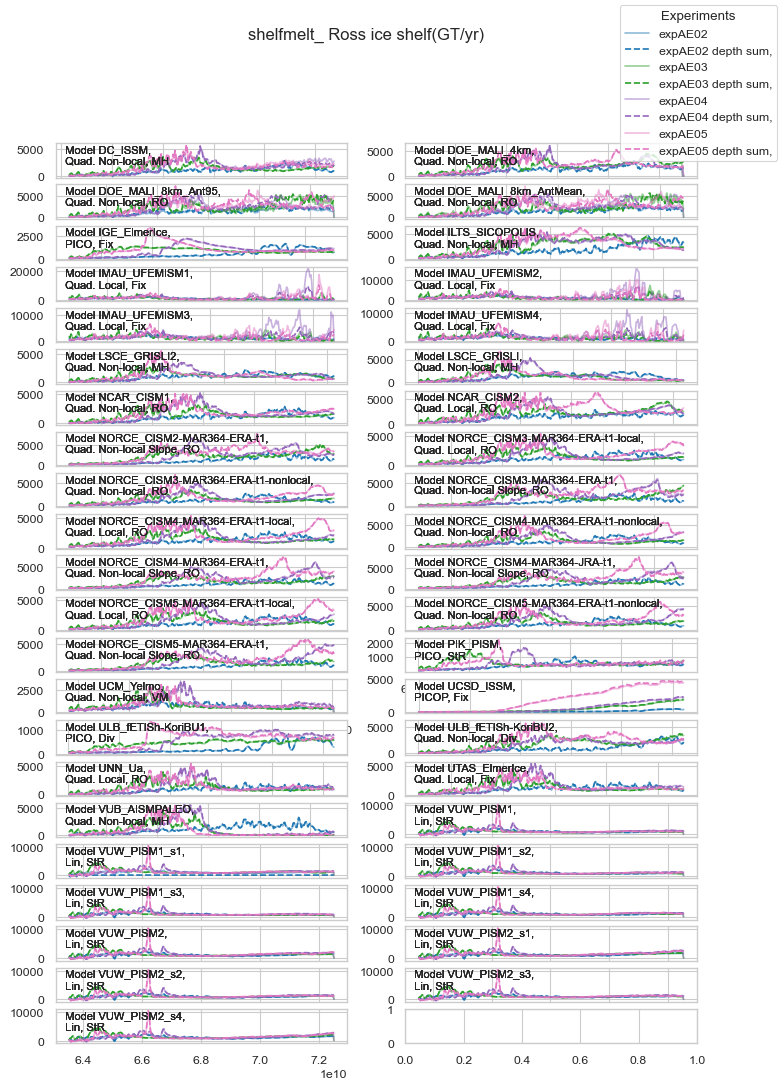

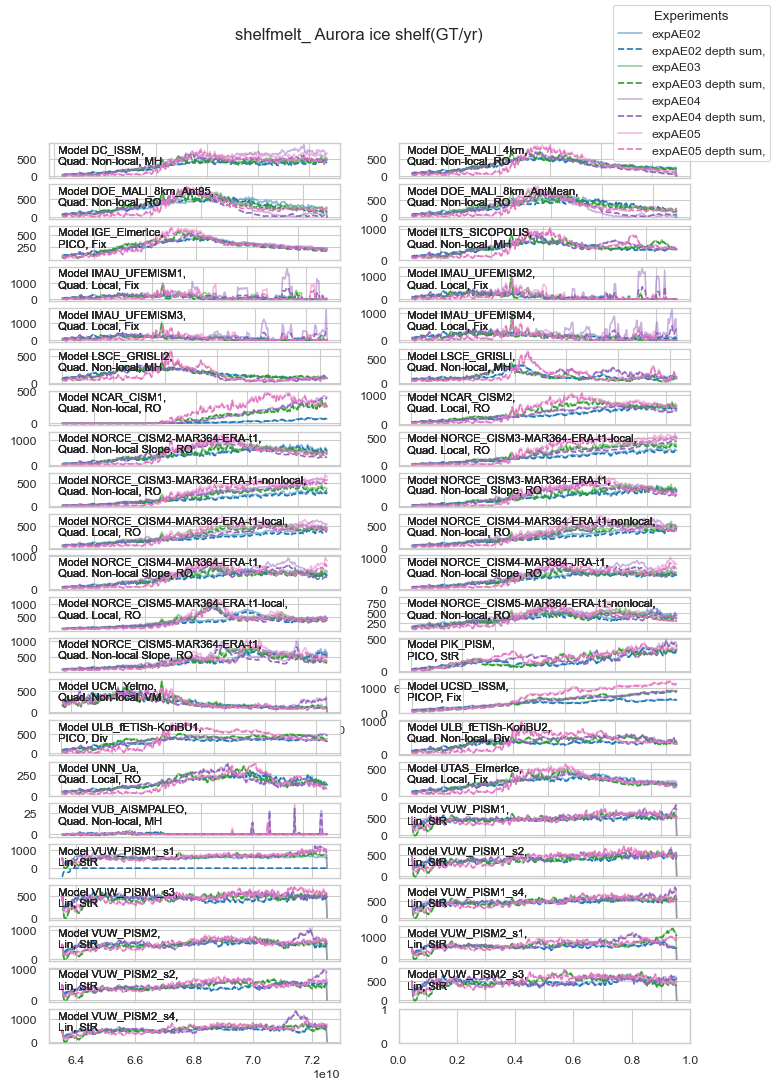

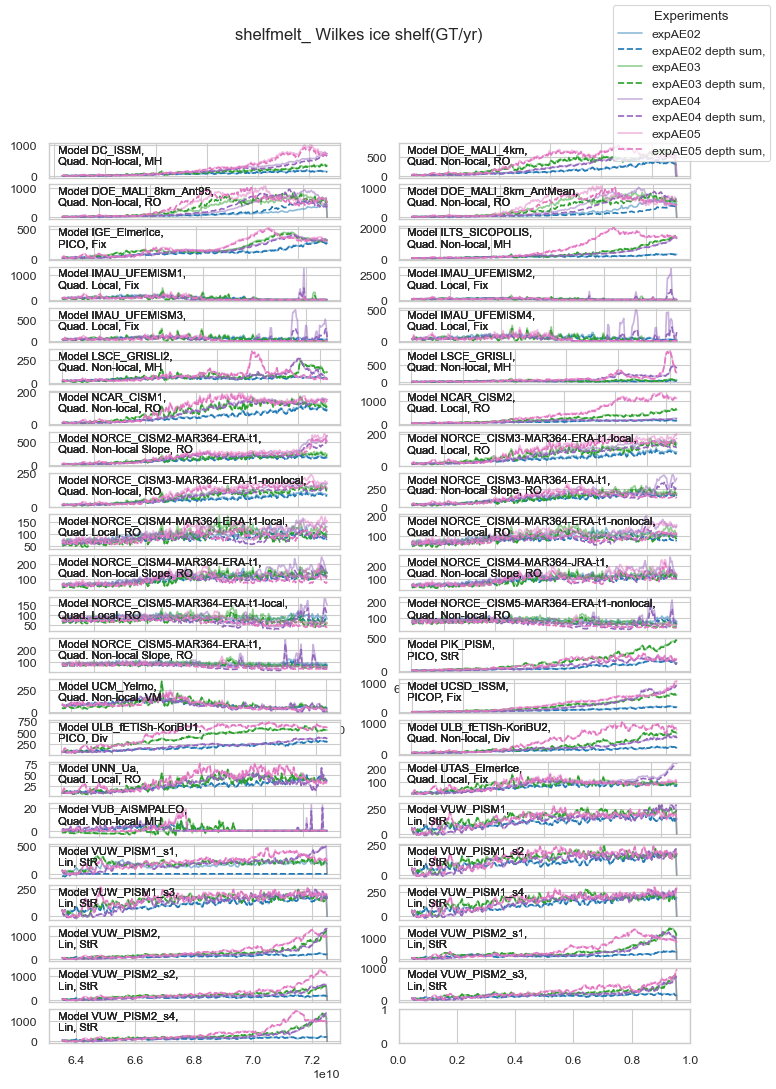

In [9]:
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")

for key in dic_area_of_interest.keys():
  
    lst = dic_area_of_interest[key]

    a4_width = 8.27  # inches
    a4_height = 11.69
    colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
    fs = 8
    regionnumbers = [2,6]
    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    f,ax = plt.subplots(df.shape[0]//2+1,2,figsize=(a4_width, a4_height))
    for j,exp in enumerate(expnames):
        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        for i in range (df.shape[0]):
            ix =i //2
            iy=i%2
            pth_way = df.iloc[i].Path
            #get shelf area

            pth_var1 = f'{pth1}/{df.iloc[i].Experiment}/{variable1}/computed_{variable1}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
            
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model
#             pth_tf = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{nmname}_{df.iloc[i].Experiment}.nc'
            pth_tf = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{nmname}_{df.iloc[i].Experiment}.nc'
            
   
       
            d3 = xr.open_dataset(pth_tf,decode_times=False )
            d1 = xr.open_dataset(pth_var1,decode_times=False )
        
        


            tmin = np.min([d3.time.size])
            #melting per area
            the_ys = np.zeros((len(dic_area_of_interest[key]),tmin))
            the_ys_var1 = np.zeros((len(dic_area_of_interest[key]),tmin))
            
          
            for k,nm in enumerate(lst):
                the_ys[k,:]= d3[f'{variable2}{nm}'].values[:,:tmin].sum(axis=0)*factor
                the_ys_var1[k,:]= d1[f'{variable2}{nm}'].values[:tmin]*factor
                
                

            y = np.sum(the_ys ,axis =0)
            y1 = np.sum(the_ys_var1 ,axis =0)
            
            ax2 = ax[ix,iy]
            ax2.plot(d3.time[:tmin],y ,color = colors[j],label = f'{exp}',alpha = 0.5)
            ax2.plot(d3.time[:tmin],y1 ,color = colors[j],label = f'{exp} depth sum,',linestyle = '--')
            
            df_info_exp = df_info[df_info['Experiment']==exp]
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model
            df_info_exp_model = df_info_exp[df_info_exp['fileID']==nmname]
#             df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
            meltparam =  df_info_exp_model['Melt parameterisation'].values[0]
            icefront =  df_info_exp_model['ice front'].values[0]

            ax2.text(0.02, 0.98,f' Model {df.iloc[i].Model},\n {meltparam}, {icefront}',transform=ax2.transAxes,fontsize = fs, va='top')
    #         ax[ix, iy].text(0.02, 0.98, f'Experiment {exp} - Model {df.iloc[i].Model}', transform=ax[ix, iy].transAxes, fontsize=12, va='top')

    #         f.text(0.02, 0.98,
    handles, labels = ax[0, 0].get_legend_handles_labels()
    f.legend(handles, labels, loc='upper right', title='Experiments')

    f.suptitle(f'{fname} {key} ice shelf(GT/yr)',fontsize = 12)
    f.savefig(f'{fpath}{fname}_{key}.pdf')
#     for j in range(1,19):